# Analyse exploratoire — Iris Dataset
EDA préalable à la recherche automatisée de modèles ML.

## 1. Setup & imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

## 2. Chargement des données

In [12]:
df = pd.read_csv("../data/00_raw/Iris.csv")
df.drop(columns=["Id"], inplace=True)
print(df.shape)
df.head()

(150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [14]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3. Qualité des données

In [15]:
print("Valeurs manquantes :")
print(df.isnull().sum())

print(f"\nDoublons : {df.duplicated().sum()}")

print("\nDistribution des classes :")
print(df["Species"].value_counts())

Valeurs manquantes :
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Doublons : 3

Distribution des classes :
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 4. Analyse exploratoire (EDA)

### 4.1 Distribution des features

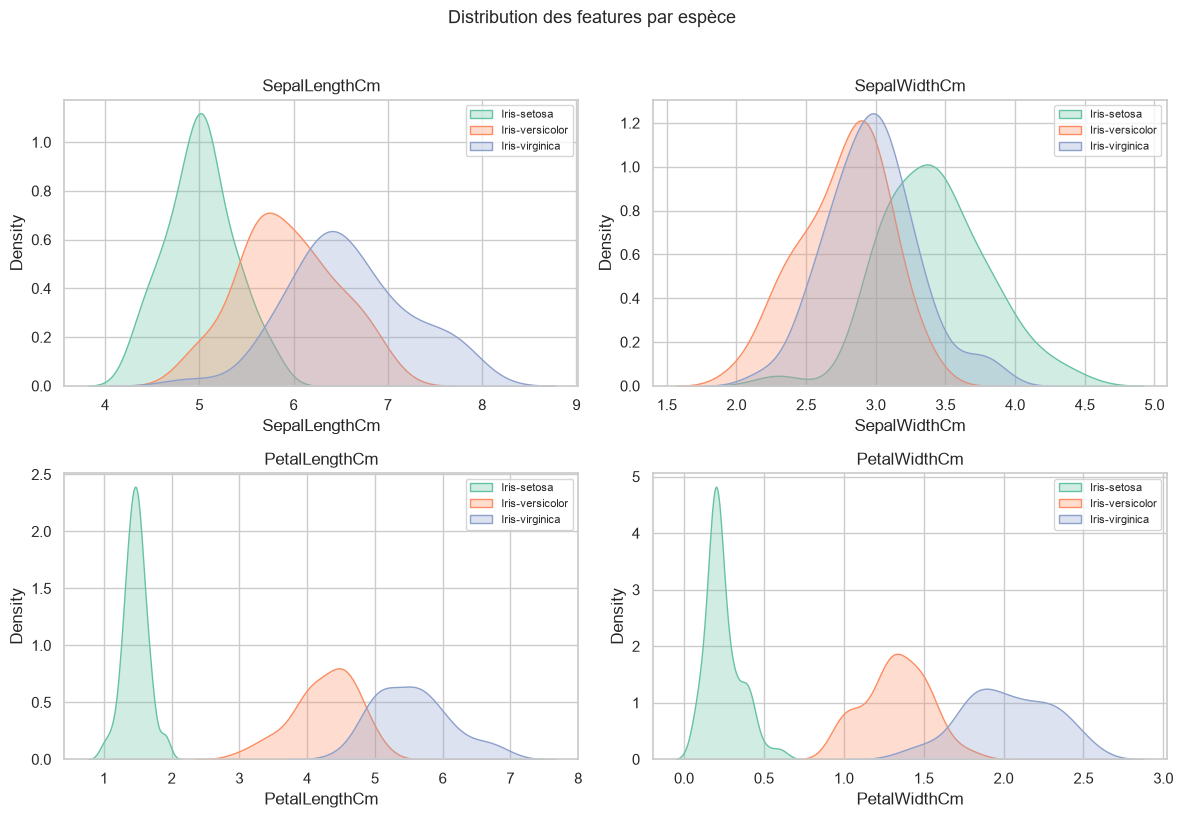

In [16]:
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, features):
    for species, grp in df.groupby("Species"):
        sns.kdeplot(grp[feat], ax=ax, label=species, fill=True, alpha=0.3)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.suptitle("Distribution des features par espèce", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Heatmap des corrélations

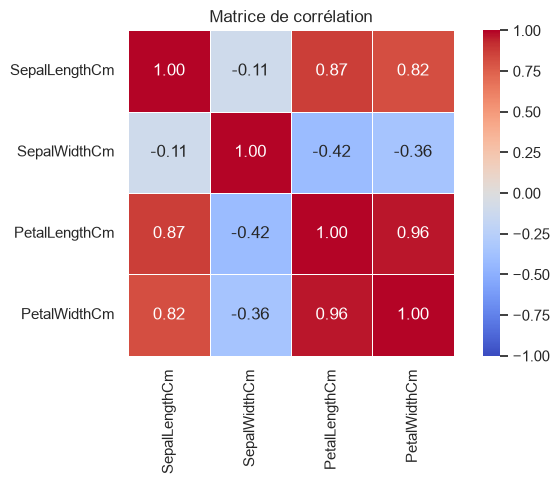

In [17]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[features].corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    square=True, linewidths=0.5
)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

### 4.3 Pairplot

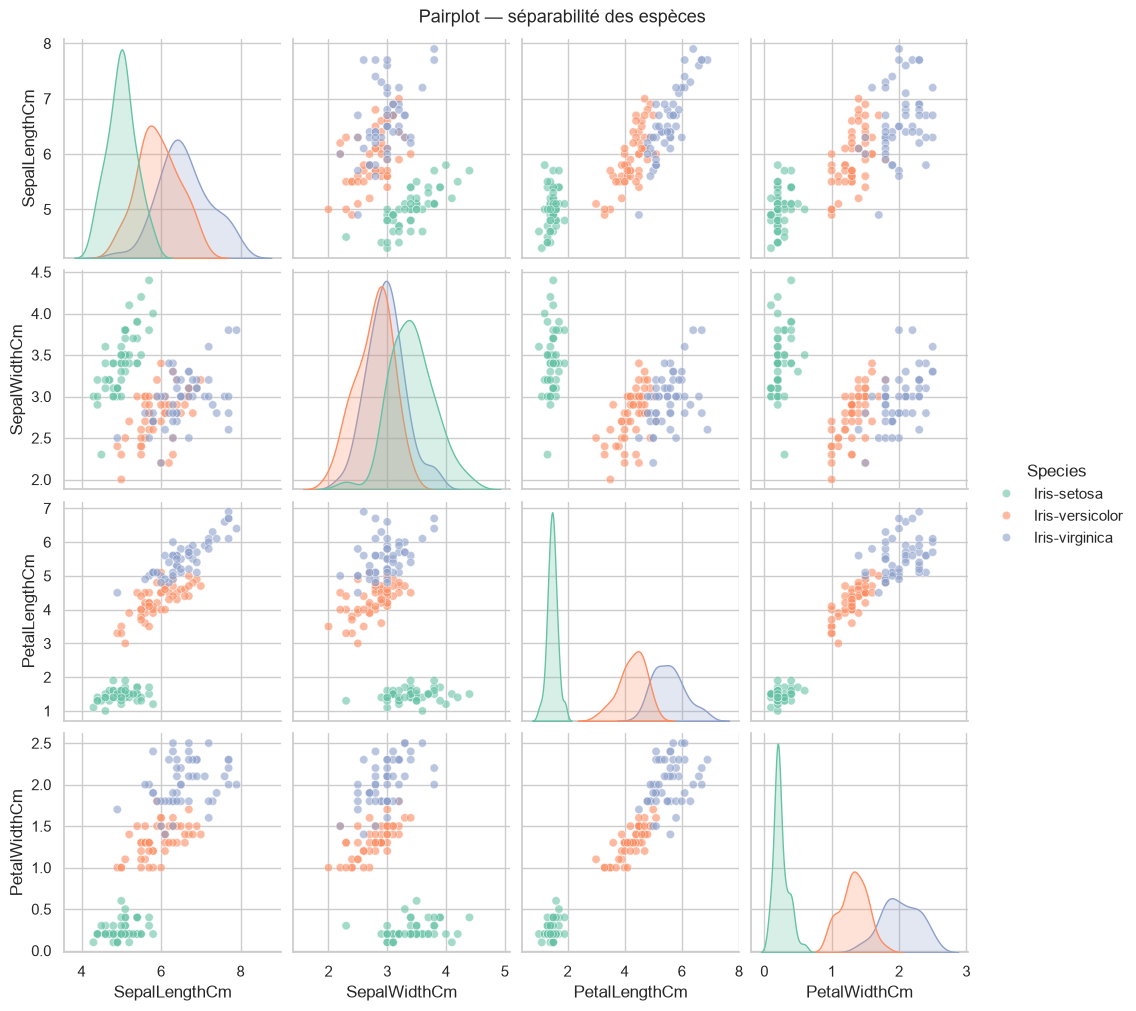

In [18]:
sns.pairplot(df, hue="Species", diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Pairplot — séparabilité des espèces", y=1.01, fontsize=13)
plt.show()

### 4.4 Boxplots par espèce

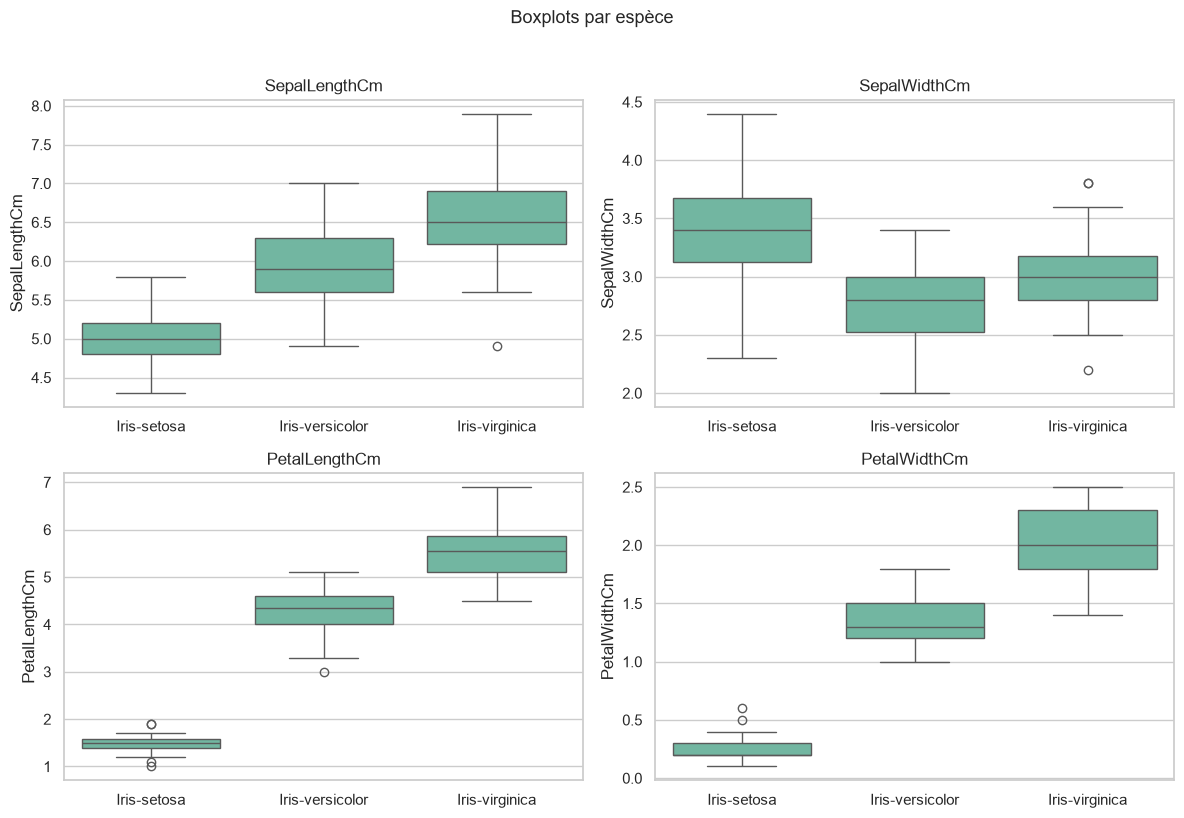

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=df, x="Species", y=feat, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
plt.suptitle("Boxplots par espèce", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Tableau récapitulatif EDA

In [20]:
summary = (
    df.groupby("Species")[features]
    .agg(["mean", "std"])
    .round(2)
)
summary.columns = [" ".join(col) for col in summary.columns]
summary

,SepalLengthCm mean,SepalLengthCm std,SepalWidthCm mean,SepalWidthCm std,PetalLengthCm mean,PetalLengthCm std,PetalWidthCm mean,PetalWidthCm std
Species,,,,,,,,
Iris-setosa,5.01,0.35,3.42,0.38,1.46,0.17,0.24,0.11
Iris-versicolor,5.94,0.52,2.77,0.31,4.26,0.47,1.33,0.20
Iris-virginica,6.59,0.64,2.97,0.32,5.55,0.55,2.03,0.27


## 6. Conclusion

**Features les plus discriminantes :**
- `PetalLengthCm` et `PetalWidthCm` séparent très bien les 3 espèces (distributions quasi non-chevauchantes entre setosa et les deux autres, légère ambiguïté entre versicolor et virginica).
- `SepalLengthCm` offre une séparation partielle.
- `SepalWidthCm` est la feature la moins discriminante (distributions très chevauchantes).

**Corrélations :**
- Forte corrélation positive entre les deux features Petal (~0.96) — potentiel de réduction de dimensionnalité.
- Corrélation modérée entre SepalLength et les features Petal.

**Qualité des données :**
- Aucune valeur manquante, dataset équilibré (50 samples par classe).
- 3 doublons potentiels à surveiller (vérifier si intentionnels).

**Implications pour le ML :**
- Tâche de classification multi-classes (3 classes) bien séparable — on s'attend à un F1 macro élevé (> 0.95) avec la plupart des classifieurs.
- Les features Petal seront probablement les plus importantes dans les modèles arborescents.
- La séparation de setosa est triviale ; le vrai défi est versicolor vs virginica.